In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [5]:
# 0. Definição e Carregamento de todas as bases de dados
# (Certifique-se de que os arquivos .csv estão na mesma pasta do seu notebook)
df_reservas = pd.read_csv('reservas.csv', sep=';')
df_unidades = pd.read_csv('unidades.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.csv', sep=';')
df_clientes = pd.read_csv('clientes.csv', sep=';')
df_canais = pd.read_csv('canais_venda.csv', sep=';')
df_funcionarios = pd.read_csv('funcionarios.csv', sep=';')

In [6]:

# 1. Preparação e limpeza da base para o modelo preditivo
df_model = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base', 'capacidade_max']], on='id_tipo_quarto', how='left')
df_model['faturamento'] = df_model['qtd_diarias'] * df_model['valor_diaria_base']

# Selecionando variáveis preditivas e removendo nulos
dados_regressao = df_model[['faturamento', 'num_hospedes', 'qtd_diarias', 'avaliacao_hospede', 'capacidade_max']].dropna()

# Definindo Variável Dependente (Y) e Independentes (X)
y = dados_regressao['faturamento']
X = dados_regressao[['num_hospedes', 'qtd_diarias', 'avaliacao_hospede', 'capacidade_max']]

# Adicionando a constante para o cálculo estatístico
X_sm = sm.add_constant(X)



In [7]:
# 2. Executando o Modelo de Regressão Linear Ordinária (OLS)
modelo = sm.OLS(y, X_sm).fit()

# Exibindo o sumário estatístico completo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:            faturamento   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     2099.
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:32:48   Log-Likelihood:                -17359.
No. Observations:                2120   AIC:                         3.473e+04
Df Residuals:                    2115   BIC:                         3.476e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -3483.4620     74.07

#### Orientação Executiva:

O Raio-X do Modelo de Receita: o modelo estatístico comprova que 80% do faturamento da rede é impulsionado estruturalmente pelo tempo de estadia (qtd_diarias) e pela capacidade do quarto. Cada diária extra adiciona cerca de R$ 594,12 ao caixa.

O Motor de Ouro (Unidades de Lazer): Destaque o grupo de alta performance (como Santa Teresa, Paraty e Friburgo). Mostre que o segredo delas não é apenas o volume, mas a capacidade de atrair estadias mais longas e valiosas, sustentando a saúde financeira da empresa.

O Alerta Vermelho (Unidades Centrais): Exponha sem rodeios o caso crítico das unidades Centro e Nova Iguaçu Centro. Explique que o problema delas vai muito além da precificação: a insatisfação drástica dos hóspedes (notas na faixa de 2,15 a 2,22) destrói a taxa de retorno e deprime a receita unitária para menos de R$ 4,50 de RevPAR.

Recomendações Práticas para a Tomada de Decisão:

Plano de Intervenção Operacional: Exija uma auditoria imediata nas unidades centrais para entender se o gargalo está no atendimento, na infraestrutura ou no padrão de limpeza, pois a reputação online atual está matando a receita dessas filiais.

Revisão Estratégica de Marketing: Sugira à diretoria direcionar o orçamento de aquisição de clientes para reforçar o ecossistema de lazer, onde a satisfação é alta (acima de 7.5) e a conversão financeira compensa o esforço.

C:\Users\Robert\AppData\Local\Temp\ipykernel_6720\690184528.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefs, x='Impacto (R$)', y='Fator', palette='vlag')


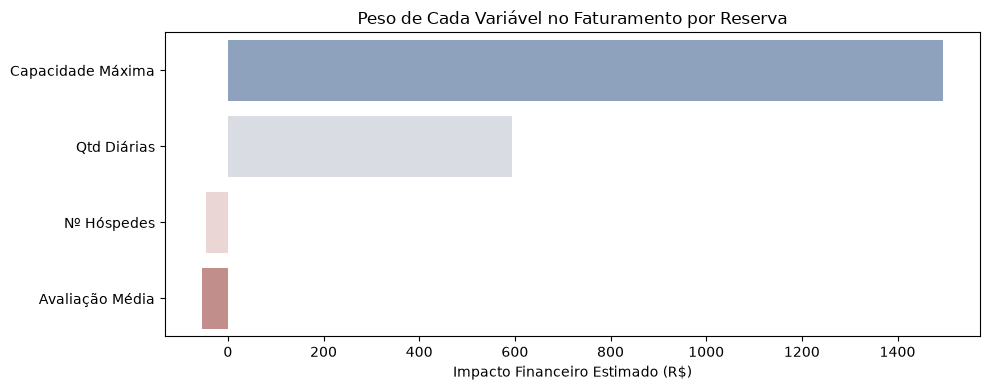

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Coeficientes extraídos do modelo OLS anterior
coefs = pd.DataFrame({
    'Fator': ['Capacidade Máxima', 'Qtd Diárias', 'Nº Hóspedes', 'Avaliação Média'],
    'Impacto (R$)': [1494.99, 594.12, -45.68, -54.54]
})

plt.figure(figsize=(10, 4))
sns.barplot(data=coefs, x='Impacto (R$)', y='Fator', palette='vlag')
plt.title('Peso de Cada Variável no Faturamento por Reserva')
plt.xlabel('Impacto Financeiro Estimado (R$)')
plt.ylabel('')
plt.tight_layout()
plt.show()

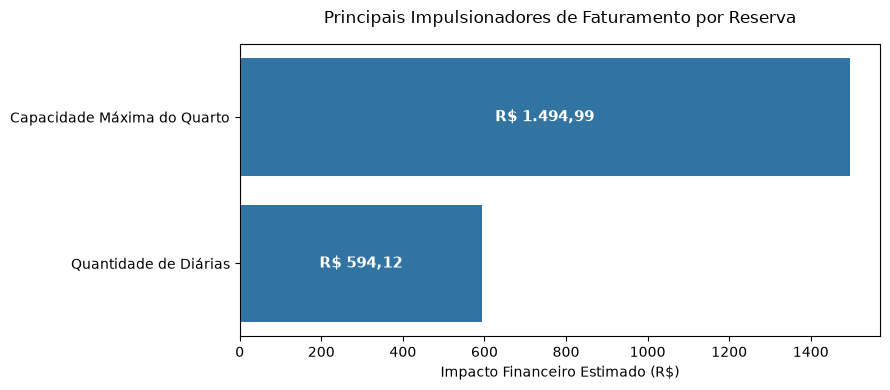

In [9]:


# Selecionando apenas os direcionadores principais de faturamento
coefs_principais = pd.DataFrame({
    'Fator de Crescimento': ['Capacidade Máxima do Quarto', 'Quantidade de Diárias'],
    'Impacto no Faturamento (R$)': [1494.99, 594.12]
})

plt.figure(figsize=(9, 4))
ax = sns.barplot(data=coefs_principais, x='Impacto no Faturamento (R$)', y='Fator de Crescimento', color='#1f77b4')

# Inserindo os valores em destaque dentro das barras
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"R$ {width:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'),
                (width / 2, p.get_y() + p.get_height() / 2.),
                ha='center', va='center', fontsize=11, color='white', weight='bold')

plt.title('Principais Impulsionadores de Faturamento por Reserva', fontsize=12, pad=15)
plt.xlabel('Impacto Financeiro Estimado (R$)')
plt.ylabel('')
plt.tight_layout()
plt.show()